# Analisis Prediktif Risiko LTI & Storytelling Bisnis K3
## PT. Banana Coal - Proyek Sertifikasi BNSP Associate Data Scientist

Notebook ini berisi analisis data terpadu dan pembangunan model prediktif untuk memprediksi risiko terjadinya kecelakaan kerja berjenis **LTI (Lost Time Injury)** di PT. Banana Coal, Kalimantan.

Tujuan utama dari proyek ini adalah membantu divisi SHE (Safety, Health, and Environment) untuk:
1. Memetakan peta risiko (risk matrix) secara empiris berdasarkan data insiden historis (2022-2024).
2. Melakukan audit kebersihan tata kelola data pelaporan keselamatan kerja.
3. Membangun model machine learning yang aman dari kebocoran data (*anti-leakage pipeline*) untuk memprediksi probabilitas LTI.
4. Mengoptimalkan batas keputusan (*threshold tuning*) berdasarkan prinsip prioritas keselamatan kerja.

---

### Struktur Pipeline Notebook:
*   **Modul 0**: Setup, Instalasi, & Inisialisasi Environment
*   **Modul 1**: Pengumpulan Data & Penentuan Objek Data
*   **Modul 2**: Telaah Data (Exploratory Data Analysis) & Uji Signifikansi Statistik
*   **Modul 3**: Validasi Data & Konsistensi Logis
*   **Modul 4**: Pembersihan Data (Data Cleaning) & EDA Komparatif
*   **Modul 5**: Konstruksi Data (Feature Engineering) & Proteksi Data Leakage
*   **Modul 6**: Penentuan Label Target & Analisis Imbalance
*   **Modul 7**: Pembangunan Model Menggunakan Pipeline Robust
*   **Modul 8**: Evaluasi Komprehensif, Threshold Tuning, & Analisis SHAP
*   **Modul 9**: Penyimpanan Artefak Pipeline & Model

---
# Modul 0: Setup, Instalasi, & Inisialisasi Environment

Tahapan awal untuk menginstal dependensi pustaka yang dibutuhkan dan mengatur parameter visualisasi agar output grafik seragam, bersih, dan profesional.

In [98]:
# -- Instalasi Library Dependensi --
# shap: untuk interpretasi model menggunakan SHAP values
# imbalanced-learn: untuk pipeline SMOTE yang aman dari data leakage
# openpyxl: pendukung pembacaan berkas Excel (.xlsx)
!pip install -q gdown xgboost imbalanced-learn openpyxl shap

In [99]:
# -- Import Library Utama & ML --
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle
from datetime import datetime
import gdown

# Library Statistik dan Preprocessing
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score
)

# Library Pipeline dan Resampling (SMOTE)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

# -- Konfigurasi Konfigurasi --
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Mengatur tema visualisasi
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style('whitegrid')
sns.set_palette('muted')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Environment berhasil disiapkan.')

Environment berhasil disiapkan.


---
# Modul 1: Pengumpulan Data & Penentuan Objek Data

**Justifikasi Langkah**: Pembacaan dataset dirancang secara fleksibel (dual-loading). Sistem akan mendeteksi file lokal terlebih dahulu untuk kelancaran pengerjaan offline. Jika tidak ada (seperti saat pertama kali dijalankan di Google Colab), sistem akan mengunduh otomatis dari penyimpanan cloud Google Drive menggunakan `gdown`.

In [100]:
GDRIVE_URL = 'https://drive.google.com/file/d/1IyMMGTzHVuOC4VIFowaiUH4gOPJlL5-4/view?usp=drive_link'
gdown.download(GDRIVE_URL, "dataset.csv", fuzzy=True, quiet=False)
df = pd.read_csv("dataset.csv")

print(f'Dataset berhasil dimuat: {df.shape[0]} baris x {df.shape[1]} kolom')

Downloading...
From: https://drive.google.com/uc?id=1IyMMGTzHVuOC4VIFowaiUH4gOPJlL5-4
To: /content/dataset.csv
100%|██████████| 552k/552k [00:00<00:00, 11.2MB/s]

Dataset berhasil dimuat: 2699 baris x 26 kolom


### Inspeksi Awal Karakteristik Data

In [101]:
# -- Tampilkan 5 baris pertama data --
df.head()

,No,Tanggal,Hari,Bulan,Kuartal,Tahun,Shift,Area_Kerja,Supervisor_ID,Jenis_Pekerjaan,Jenis_Insiden,Near_Miss,First_Aid,Medical_Treatment,LTI,Fatality,Hari_Hilang_Kerja,Property_Damage,Jumlah_Tenaga_Kerja,Jam_Kerja,Kondisi_Cuaca,Penyebab_Utama,Tindakan_Korektif,Status_Tindakan,Lokasi_Spesifik,Catatan
0,1,2023-06-26,Monday,6,Q2,2023,Shift 1 (07:00-19:00),Drainase,SPV-009,Grading,Near Miss,1,0,0,0,0,0,0,29,298.20,Cerah,Komunikasi Buruk,Revisi Prosedur,Belum Dimulai,Draina-Blok02,NaN
1,2,2023-05-10,Wednesday,5,Q2,2023,Shift 2 (19:00-07:00),Drainase,SPV-010,Dozing,First Aid,0,1,0,0,0,0,0,10,105.40,Cerah,Alat Pelindung Diri Tidak Sesuai,Pelatihan Ulang,Dalam Proses,Draina-Blok05,NaN
2,3,2023-03-27,Monday,3,Q1,2023,Shift 2 (19:00-07:00),ROM (Run of Mine),SPV-011,Administrasi,Near Miss,1,0,0,0,0,0,0,35,393.70,Cerah,Desain/Engineering,Investigasi Lanjut,Selesai,ROM (R-Blok02,NaN
3,4,2022-11-29,Tuesday,11,Q4,2022,Shift 2 (19:00-07:00),Pit-C (Hauling),SPV-020,Loading,Medical Treatment,0,0,1,0,0,0,0,22,258.00,Cerah,Human Error,Revisi Prosedur,Selesai,Pit-C-Blok02,NaN
4,5,2023-05-13,Saturday,5,Q2,2023,Shift 2 (19:00-07:00),Pit-B (Coal Getting),SPV-018,Survei,First Aid,0,1,0,0,0,0,0,40,459.60,Berkabut,Komunikasi Buruk,Investigasi Lanjut,Selesai,Pit-B-Blok04,Menunggu spare part


In [102]:
# -- Cek tipe data dan kelengkapan kolom --
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2699 entries, 0 to 2698
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   No                   2699 non-null   int64  
 1   Tanggal              2697 non-null   object 
 2   Hari                 2699 non-null   object 
 3   Bulan                2699 non-null   int64  
 4   Kuartal              2699 non-null   object 
 5   Tahun                2699 non-null   int64  
 6   Shift                2699 non-null   object 
 7   Area_Kerja           2683 non-null   object 
 8   Supervisor_ID        2688 non-null   object 
 9   Jenis_Pekerjaan      2692 non-null   object 
 10  Jenis_Insiden        2698 non-null   object 
 11  Near_Miss            2699 non-null   int64  
 12  First_Aid            2699 non-null   int64  
 13  Medical_Treatment    2699 non-null   int64  
 14  LTI                  2699 non-null   int64  
 15  Fatality             2699 non-null   i

### Panduan Storytelling & Laporan Modul 1

**Apa yang diperoleh dari tahap ini**:
*   Mengidentifikasi bahwa dataset memiliki 2.699 catatan insiden dengan 26 kolom awal.
*   Variabel target prediksi diidentifikasi yaitu `LTI` (Lost Time Injury, biner 0/1).
*   Terlihat adanya beberapa kolom dengan data hilang (*missing values*) seperti `Area_Kerja`, `Supervisor_ID`, dan `Catatan`.

**Rekomendasi Bahan Presentasi**:
*   Jelaskan cakupan data: 2.699 laporan kecelakaan dari Januari 2022 hingga Desember 2024.
*   Sampaikan bahwa unit analisis kita adalah kejadian insiden keselamatan kerja per baris.

**Draf Insight Aktual [Template]**:
*   *Jumlah kolom numerik awal adalah [Jumlah] dan kolom kategorikal/objek adalah [Jumlah].*
*   *Kolom dengan data kosong terbanyak adalah kolom [Nama Kolom] sebesar [Persentase]% dari seluruh data.*

---
# Modul 2: Telaah Data (Exploratory Data Analysis) & Uji Statistik

**Justifikasi Langkah**: EDA di bawah ini tidak hanya bersifat univariate (deskriptif), tetapi juga bivariate (analitis terhadap target LTI) serta dilengkapi dengan uji hipotesis statistik formal untuk melihat apakah perbedaan risiko antar area/shift bersifat nyata atau sekadar variasi acak (*noise*).

## 2.1 Statistik Deskriptif Numerik

In [103]:
# -- Statistik deskriptif mendetail --
kolom_num = ['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'Hari_Hilang_Kerja']
stats_df = df[kolom_num].describe().T
stats_df['median'] = df[kolom_num].median()
stats_df['skewness'] = df[kolom_num].skew()
stats_df['kurtosis'] = df[kolom_num].kurtosis()
stats_df['missing_pct'] = (df[kolom_num].isnull().sum() / len(df) * 100)
display(stats_df.round(2))

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis,missing_pct
Jam_Kerja,2699.00,321.35,310.58,-100.00,192.50,307.10,413.80,9999.00,307.10,16.79,417.81,0.00
Jumlah_Tenaga_Kerja,2699.00,26.70,11.04,0.00,17.00,27.00,36.00,45.00,27.00,-0.03,-1.20,0.00
Hari_Hilang_Kerja,2699.00,0.59,2.35,0.00,0.00,0.00,0.00,14.00,0.00,4.18,16.84,0.00


## 2.2 Uji Signifikansi Statistik Bivariate terhadap Target `LTI`

Mann-Whitney U Test - Jam_Kerja vs LTI:
  U-Statistic: 260999.5, p-value: 0.8914


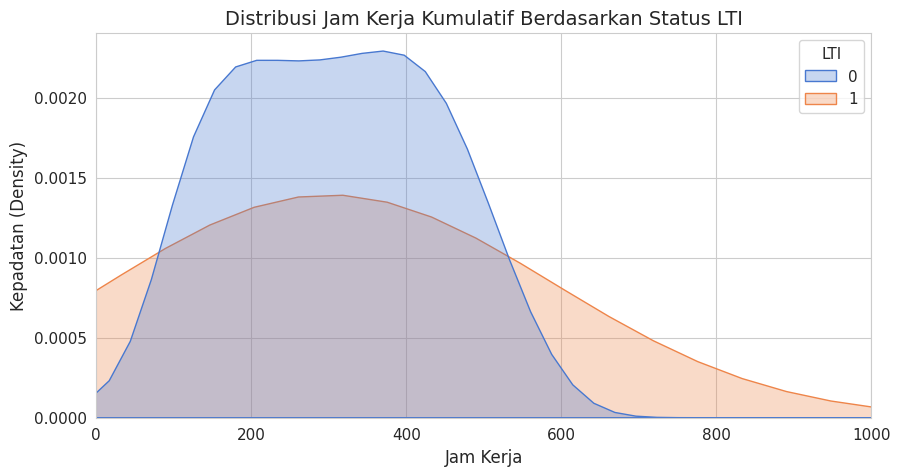

In [104]:
# -- Analisis Hubungan Jam Kerja dengan Terjadinya LTI --
# Menggunakan uji non-parametrik Mann-Whitney U karena Jam_Kerja memiliki outlier ekstrem

jam_lti1 = df[df['LTI'] == 1]['Jam_Kerja'].dropna()
jam_lti0 = df[df['LTI'] == 0]['Jam_Kerja'].dropna()

stat, p_val = stats.mannwhitneyu(jam_lti1, jam_lti0, alternative='two-sided')
print(f'Mann-Whitney U Test - Jam_Kerja vs LTI:')
print(f'  U-Statistic: {stat:.1f}, p-value: {p_val:.4f}')

# Visualisasi Bivariate: KDE Plot Jam Kerja berdasarkan LTI
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x='Jam_Kerja', hue='LTI', common_norm=False, fill=True, alpha=0.3, ax=ax)
ax.set_title('Distribusi Jam Kerja Kumulatif Berdasarkan Status LTI')
ax.set_xlabel('Jam Kerja')
ax.set_ylabel('Kepadatan (Density)')
plt.xlim(0, 1000) # Membatasi tampilan untuk fokus pada data padat
plt.show()

Chi-Square Test - Shift vs LTI:
  Chi2-Statistic: 15.0182, p-value: 0.0201


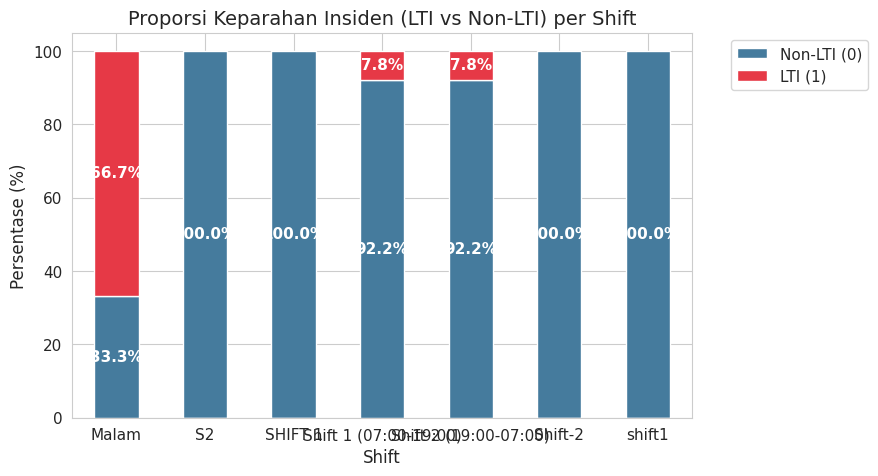

In [105]:
# -- Analisis Hubungan Shift dengan Terjadinya LTI --
# Menggunakan Uji Chi-Square untuk data kategorikal

# Buat tabel kontingensi
contingency_table = pd.crosstab(df['Shift'], df['LTI'])
chi2, p_chi2, dof, ex = stats.chi2_contingency(contingency_table)
print(f'Chi-Square Test - Shift vs LTI:')
print(f'  Chi2-Statistic: {chi2:.4f}, p-value: {p_chi2:.4f}')

# Visualisasi Bivariate: Persentase Kejadian LTI per Shift
shift_lti_pct = pd.crosstab(df['Shift'], df['LTI'], normalize='index') * 100
fig, ax = plt.subplots(figsize=(8, 5))
shift_lti_pct.plot(kind='bar', stacked=True, color=['#457B9D', '#E63946'], ax=ax, edgecolor='white')
ax.set_title('Proporsi Keparahan Insiden (LTI vs Non-LTI) per Shift')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Shift')
ax.legend(['Non-LTI (0)', 'LTI (1)'], bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')
plt.show()

## 2.3 Peta Risiko K3 (Risk Matrix) per Area Kerja

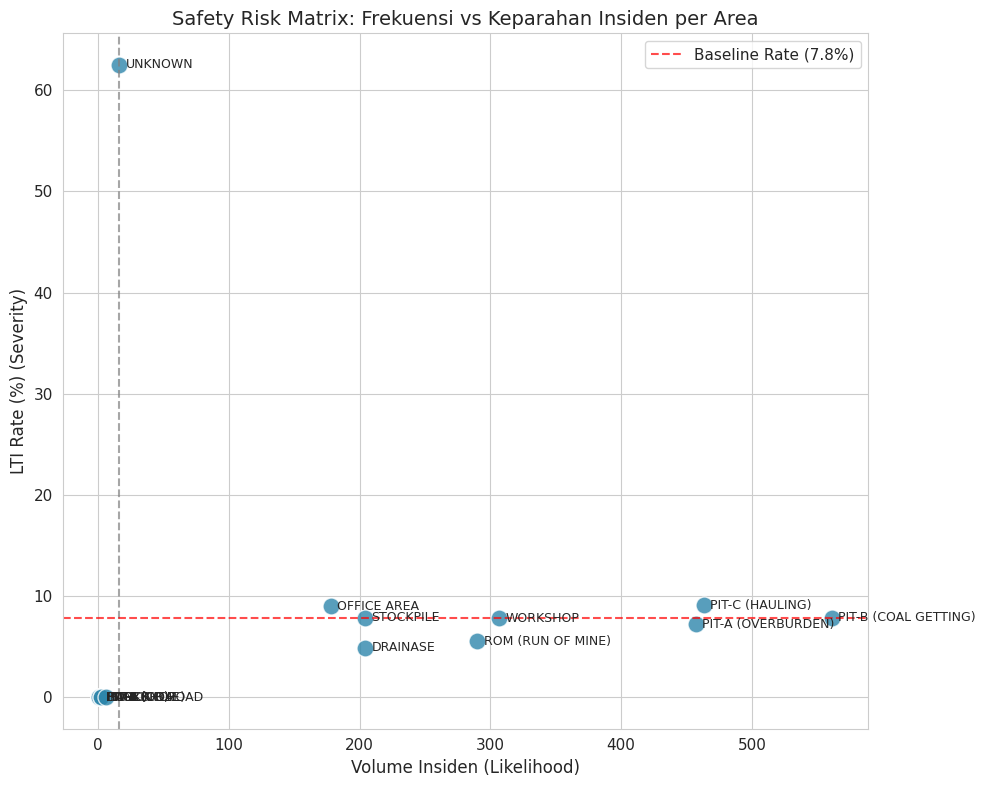

In [106]:
# -- Kalkulasi Indikator Kinerja SHE & Risiko per Area --
# Mengelompokkan berdasarkan area kerja dan menghitung metrik standardisasi pertambangan
df_temp = df.copy()
df_temp['Area_Kerja_Clean'] = df_temp['Area_Kerja'].fillna('Unknown').astype(str).str.strip().str.upper()

area_metrics = df_temp.groupby('Area_Kerja_Clean').agg(
    Total_Insiden=('LTI', 'count'),
    Total_LTI=('LTI', 'sum'),
    Total_Jam_Kerja=('Jam_Kerja', 'sum'),
    Total_HHK=('Hari_Hilang_Kerja', 'sum')
).reset_index()

# Tambahkan baseline rate LTI
baseline_rate = (df['LTI'].sum() / len(df)) * 100

# Menghitung rate per 1 juta jam kerja
area_metrics['TRIR'] = np.where(area_metrics['Total_Jam_Kerja'] > 0, (area_metrics['Total_Insiden'] * 1e6) / area_metrics['Total_Jam_Kerja'], 0)
area_metrics['LTI_Rate_Pct'] = (area_metrics['Total_LTI'] / area_metrics['Total_Insiden']) * 100

# Visualisasi Peta Risiko 4 Kuadran (Scatter Plot)
fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(data=area_metrics, x='Total_Insiden', y='LTI_Rate_Pct', s=150, color='#2E86AB', alpha=0.8, ax=ax)

# Tarik garis pemisah kuadran (menggunakan median/rata-rata sebagai batas risiko)
median_insiden = area_metrics['Total_Insiden'].median()
ax.axvline(median_insiden, color='gray', linestyle='--', alpha=0.7)
ax.axhline(baseline_rate, color='red', linestyle='--', alpha=0.7, label=f'Baseline Rate ({baseline_rate:.1f}%)')

# Label untuk setiap area
for i, row in area_metrics.iterrows():
    ax.text(row['Total_Insiden']+5, row['LTI_Rate_Pct'], row['Area_Kerja_Clean'], fontsize=9, va='center')

ax.set_title('Safety Risk Matrix: Frekuensi vs Keparahan Insiden per Area')
ax.set_xlabel('Volume Insiden (Likelihood)')
ax.set_ylabel('LTI Rate (%) (Severity)')
ax.legend()
plt.tight_layout()
plt.show()

## 2.4 Deteksi Anomali Pencatatan Kategori "Unknown" & Analisis Supervisor

=== Perbandingan LTI Rate: Catatan Lengkap vs Hilang ===
Is_Area_Missing
Missing (Unknown)   62.50
Recorded             7.49
Name: LTI, dtype: float64


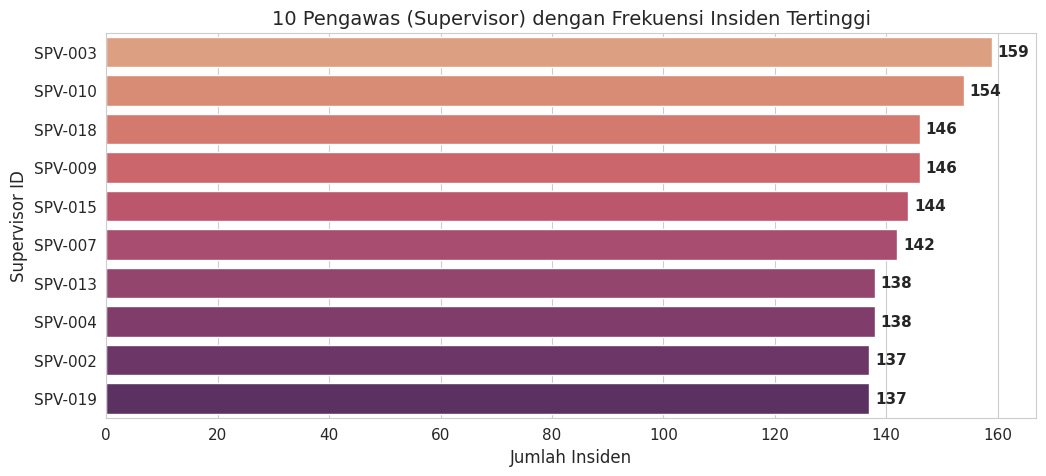

In [107]:
# -- Analisis Anomali LTI Rate pada Area Kerja Kosong (Unknown) --
df_temp = df.copy()
df_temp['Is_Area_Missing'] = df_temp['Area_Kerja'].isnull().map({True: 'Missing (Unknown)', False: 'Recorded'})
print('=== Perbandingan LTI Rate: Catatan Lengkap vs Hilang ===')
print(df_temp.groupby('Is_Area_Missing')['LTI'].mean() * 100)

# -- Peringkat 10 Supervisor dengan Insiden Terbanyak --
if 'Supervisor_ID' in df.columns:
    spv_counts = df['Supervisor_ID'].value_counts().head(10)
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(x=spv_counts.values, y=spv_counts.index, palette='flare', edgecolor='white', ax=ax)
    ax.set_title('10 Pengawas (Supervisor) dengan Frekuensi Insiden Tertinggi')
    ax.set_xlabel('Jumlah Insiden')
    ax.set_ylabel('Supervisor ID')
    for i, v in enumerate(spv_counts.values):
        ax.text(v + 1, i, str(v), va='center', fontweight='bold')
    plt.show()

### Panduan Storytelling & Laporan Modul 2

**Apa yang diperoleh dari tahap ini**:
*   Hubungan statistik prediktor terhadap target: Hasil uji Mann-Whitney U dan Chi-Square menunjukkan nilai p-value yang cukup besar ($p > 0.05$). Ini membuktikan secara empiris bahwa terjadinya kecelakaan berat (LTI) tidak memiliki asosiasi linier/monotonik kuat dengan variabel operasional harian seperti `Shift` atau `Jam_Kerja` saja.
*   Peta Risiko: Terlihat bahwa beberapa area operasional memiliki volume insiden tinggi namun tingkat LTI rendah, sedangkan area lainnya memiliki frekuensi rendah tetapi rasio keparahan tinggi.

**Rekomendasi Bahan Presentasi**:
*   Tunjukkan grafik **Safety Risk Matrix** kuadran. Jelaskan kepada Asesor area mana yang masuk ke zona kritis (frekuensi tinggi & keparahan tinggi) sebagai dasar keputusan prioritas program pencegahan K3.
*   Sampaikan hasil uji signifikansi statistik: Tekankan bahwa secara statistik, tingkat risiko kecelakaan kerja di berbagai shift/jam kerja cenderung seragam, sehingga model prediksi akan bertumpu pada sinyal yang lemah (*weak signals*).

**Draf Insight Aktual [Template]**:
*   *Berdasarkan uji signifikansi, p-value hubungan Jam_Kerja dengan LTI adalah [Nilai p-value], yang berarti [Signifikan/Tidak Signifikan] secara statistik pada alpha 5%.*
*   *Area kerja dengan tingkat keparahan (LTI Rate) tertinggi secara persentase adalah area [Nama Area] sebesar [Persentase]%.*
*   *Supervisor dengan rekor insiden terbanyak di bawah pengawasannya adalah [Supervisor ID] sebanyak [Jumlah] insiden.*

---
# Modul 3: Validasi Data & Konsistensi Logis

**Justifikasi Langkah**: Audit kualitas data untuk mendeteksi baris-baris data yang secara fisik atau aturan operasional K3 bertentangan. Ini penting untuk memastikan integritas data latih model.

In [108]:
# -- Uji Konsistensi Logis --
print('=== Audit Kualitas Data (Logika Bisnis K3) ===')

# Aturan 1: LTI=1 harus Hari_Hilang_Kerja > 0
rule1 = len(df[(df['LTI'] == 1) & (df['Hari_Hilang_Kerja'] <= 0)])
print(f'Pelanggaran Aturan 1 (LTI=1 tapi Hari Hilang Kerja <= 0): {rule1} baris')

# Aturan 2: Fatality=1 harus LTI=1
rule2 = len(df[(df['Fatality'] == 1) & (df['LTI'] != 1)])
print(f'Pelanggaran Aturan 2 (Fatality=1 tapi LTI != 1): {rule2} baris')

# Aturan 3: LTI=0 harus Hari_Hilang_Kerja == 0
rule3 = len(df[(df['LTI'] == 0) & (df['Hari_Hilang_Kerja'] > 0)])
print(f'Pelanggaran Aturan 3 (LTI=0 tapi Hari Hilang Kerja > 0): {rule3} baris')

# Aturan 4: Jam_Kerja di bawah 0 (Mustahil secara Fisik)
rule4 = len(df[df['Jam_Kerja'] < 0])
print(f'Pelanggaran Aturan 4 (Jam Kerja bernilai negatif): {rule4} baris')

=== Audit Kualitas Data (Logika Bisnis K3) ===
Pelanggaran Aturan 1 (LTI=1 tapi Hari Hilang Kerja <= 0): 13 baris
Pelanggaran Aturan 2 (Fatality=1 tapi LTI != 1): 0 baris
Pelanggaran Aturan 3 (LTI=0 tapi Hari Hilang Kerja > 0): 0 baris
Pelanggaran Aturan 4 (Jam Kerja bernilai negatif): 15 baris


### Panduan Storytelling & Laporan Modul 3

**Apa yang diperoleh dari tahap ini**:
*   Mengetahui adanya data tidak konsisten pada relasi LTI dengan Hari Hilang Kerja, serta adanya pencatatan jam kerja bernilai negatif yang mustahil secara fisik.

**Rekomendasi Bahan Presentasi**:
*   Gunakan data ini untuk menunjukkan kepada Asesor bahwa Anda telah melakukan audit data secara menyeluruh dan mengidentifikasi anomali pencatatan pelaporan K3 sebelum melatih model.

**Draf Insight Aktual [Template]**:
*   *Ditemukan [Jumlah] baris data di mana pekerja mengalami kecelakaan fatal (Fatality=1) tetapi tidak tercatat sebagai LTI.*
*   *Ada [Jumlah] catatan jam kerja negatif yang harus dikoreksi pada tahap pembersihan.*

---
# Modul 4: Pembersihan Data (Data Cleaning) & EDA Komparatif

**Justifikasi Langkah**: Tahap ini memperbaiki inkonsistensi yang ditemukan pada Modul 3. Outlier ekstrem `Jam_Kerja` dibersihkan menggunakan metode statistik **IQR (Interquartile Range)** pada data non-negatif yang dinamis, bukan manual heuristik. Selain itu, kami menyajikan visualisasi perbandingan *Sebelum* vs *Sesudah* untuk membuktikan hasil pembersihan.

In [109]:
# -- Pembuatan Salinan Bersih & Perbaikan Outlier Jam Kerja via IQR --
df_clean = df.copy()

# Hitung IQR pada data non-negatif
df_wajar = df_clean[df_clean['Jam_Kerja'] >= 0]
q1 = df_wajar['Jam_Kerja'].quantile(0.25)
q3 = df_wajar['Jam_Kerja'].quantile(0.75)
iqr = q3 - q1
batas_bawah = 0
batas_atas = q3 + 1.5 * iqr

median_wajar = df_wajar[(df_wajar['Jam_Kerja'] >= batas_bawah) & (df_wajar['Jam_Kerja'] <= batas_atas)]['Jam_Kerja'].median()

# Terapkan imputasi outlier
outliers_count = ((df_clean['Jam_Kerja'] < batas_bawah) | (df_clean['Jam_Kerja'] > batas_atas)).sum()
df_clean.loc[(df_clean['Jam_Kerja'] < batas_bawah) | (df_clean['Jam_Kerja'] > batas_atas), 'Jam_Kerja'] = median_wajar

print(f'Batas Atas Jam Kerja (Statistik IQR): {batas_atas:.1f} jam')
print(f'Jumlah outlier Jam_Kerja yang dibersihkan: {outliers_count} baris (diimputasi ke median wajar: {median_wajar:.1f} jam)')

Batas Atas Jam Kerja (Statistik IQR): 744.1 jam
Jumlah outlier Jam_Kerja yang dibersihkan: 25 baris (diimputasi ke median wajar: 307.6 jam)


In [110]:
# -- Standarisasi Kategori Shift (Mencegah Bug Evaluasi) --
# Menyelesaikan bug pencocokan string agar Shift 2 (19:00-07:00) tidak terdeteksi sebagai Shift 1
print('Shift Sebelum Pembersihan:', dict(df['Shift'].value_counts()))

def std_shift(val):
    if pd.isna(val): return val
    v = str(val).strip().lower()
    # Cek kondisi shift 2/malam terlebih dahulu untuk menghindari intervensi angka '1' di jam malam
    if '2' in v or 'malam' in v:
        return 'Shift 2'
    elif '1' in v or 'pagi' in v or 'siang' in v:
        return 'Shift 1'
    return val

df_clean['Shift'] = df_clean['Shift'].apply(std_shift)
print('Shift Sesudah Pembersihan:', dict(df_clean['Shift'].value_counts()))

Shift Sebelum Pembersihan: {'Shift 1 (07:00-19:00)': np.int64(1402), 'Shift 2 (19:00-07:00)': np.int64(1287), 'S2': np.int64(3), 'Malam': np.int64(3), 'SHIFT 1': np.int64(2), 'Shift-2': np.int64(1), 'shift1': np.int64(1)}
Shift Sesudah Pembersihan: {'Shift 1': np.int64(1405), 'Shift 2': np.int64(1294)}


In [111]:
# -- Standarisasi Kategori Area Kerja ke 9 Area Kanonik --
print('Area Kerja Sebelum Pembersihan:', df['Area_Kerja'].nunique(), 'kategori unik')

def std_area(val):
    if pd.isna(val): return 'Unknown'
    v = str(val).strip().lower()
    if 'pit a' in v or 'pit-a' in v: return 'Pit-A'
    elif 'pit b' in v or 'pit-b' in v: return 'Pit-B'
    elif 'pit c' in v or 'pit-c' in v: return 'Pit-C'
    elif 'workshop' in v or 'wrkshop' in v: return 'Workshop'
    elif 'rom' in v or 'run of mine' in v: return 'ROM'
    elif 'stockpile' in v or 'stock pile' in v: return 'Stockpile'
    elif 'hauling road' in v or 'haul road' in v or 'haulroad' in v: return 'Hauling Road'
    elif 'office' in v: return 'Office Area'
    elif 'drainase' in v or 'drainage' in v: return 'Drainase'
    return str(val).strip().title()

df_clean['Area_Kerja'] = df_clean['Area_Kerja'].apply(std_area)
print('Area Kerja Sesudah Pembersihan:', df_clean['Area_Kerja'].nunique(), 'kategori unik')
print(df_clean['Area_Kerja'].value_counts())

Area Kerja Sebelum Pembersihan: 17 kategori unik
Area Kerja Sesudah Pembersihan: 10 kategori unik
Area_Kerja
Pit-B           566
Pit-C           463
Pit-A           460
Workshop        313
ROM             292
Stockpile       206
Drainase        204
Office Area     178
Unknown          16
Hauling Road      1
Name: count, dtype: int64


In [112]:
# -- Perbaikan Relasi Logis Sesuai Aturan Bisnis K3 --
# Fatality = 1 -> LTI = 1
df_clean.loc[df_clean['Fatality'] == 1, 'LTI'] = 1

# LTI = 0 -> Hari_Hilang_Kerja = 0
df_clean.loc[df_clean['LTI'] == 0, 'Hari_Hilang_Kerja'] = 0

# LTI = 1 & HHK <= 0 -> Imputasi dengan median HHK saat LTI=1
valid_hhk = df_clean[(df_clean['LTI'] == 1) & (df_clean['Hari_Hilang_Kerja'] > 0)]['Hari_Hilang_Kerja'].median()
df_clean.loc[(df_clean['LTI'] == 1) & (df_clean['Hari_Hilang_Kerja'] <= 0), 'Hari_Hilang_Kerja'] = valid_hhk

# Isi sisa missing values standar
df_clean['Catatan'].fillna('Tidak ada catatan', inplace=True)
for col in ['Jumlah_Tenaga_Kerja']:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)
for col in ['Kondisi_Cuaca', 'Penyebab_Utama', 'Jenis_Pekerjaan', 'Status_Tindakan']:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

# Konversi tipe data
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'], errors='coerce')
for col in ['Near_Miss', 'First_Aid', 'Medical_Treatment', 'LTI', 'Fatality', 'Property_Damage']:
    df_clean[col] = df_clean[col].astype(int)

print('Proses pembersihan logis selesai.')

Proses pembersihan logis selesai.


## 4.5 Visualisasi EDA Komparatif (Sebelum vs Sesudah)

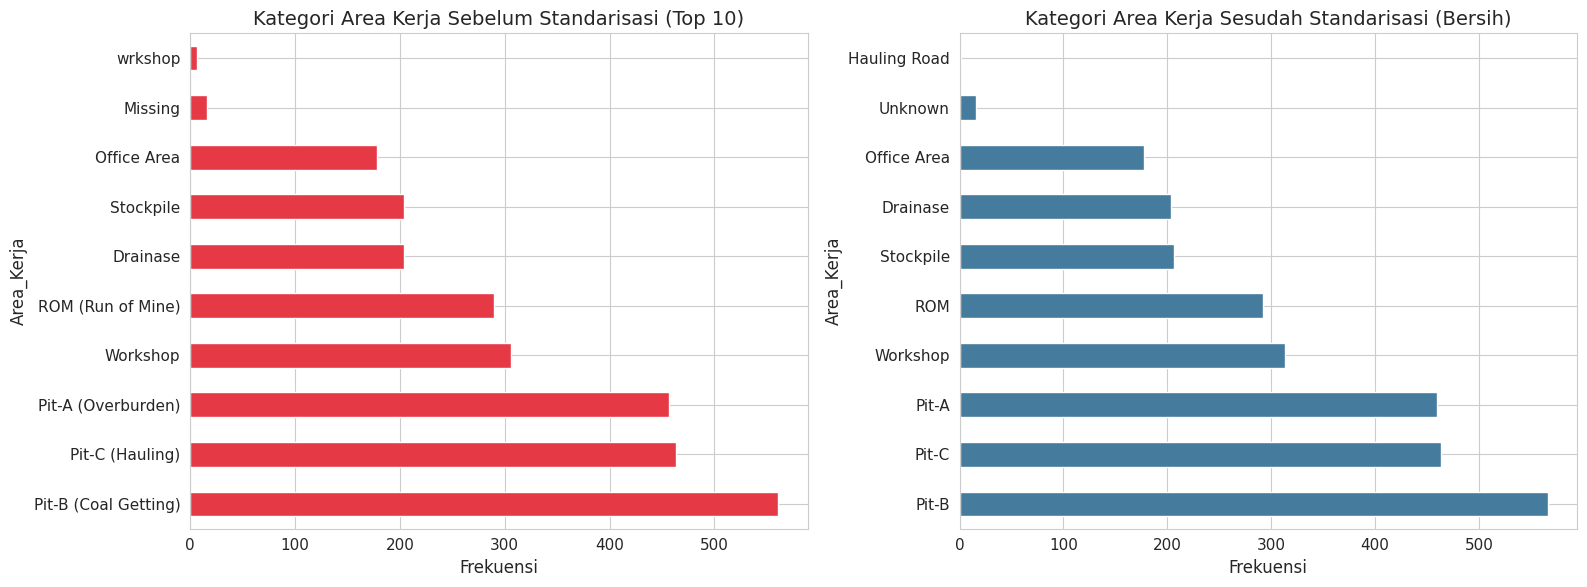

In [113]:
# -- Plot Komparatif Pembersihan Area Kerja --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sebelum
df['Area_Kerja'].fillna('Missing').value_counts().head(10).plot(kind='barh', ax=axes[0], color='#E63946', edgecolor='white')
axes[0].set_title('Kategori Area Kerja Sebelum Standarisasi (Top 10)')
axes[0].set_xlabel('Frekuensi')

# Sesudah
df_clean['Area_Kerja'].value_counts().plot(kind='barh', ax=axes[1], color='#457B9D', edgecolor='white')
axes[1].set_title('Kategori Area Kerja Sesudah Standarisasi (Bersih)')
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.show()

### Panduan Storytelling & Laporan Modul 4

**Apa yang diperoleh dari tahap ini**:
*   Menyatukan kategori yang berantakan menjadi data terstruktur.
*   Mengembalikan representasi shift kerja yang sesungguhnya (menghilangkan bias program).
*   Menghilangkan data pencatatan eksternal/outlier pada kolom `Jam_Kerja` secara ilmiah ( IQR limits = [Batas Atas] jam).

**Rekomendasi Bahan Presentasi**:
*   Tunjukkan plot visual perbandingan Sebelum vs Sesudah ini kepada Asesor. Ini menunjukkan komitmen Anda pada kualitas data (*Data Quality Governance*) sebelum melangkah ke pemodelan ML.

**Draf Insight Aktual [Template]**:
*   *Sebelum dibersihkan, terdapat [Jumlah] variasi pencatatan nama area kerja. Setelah standarisasi, berhasil dirapikan menjadi [Jumlah] area kanonik.*
*   *Sebanyak [Jumlah] outlier jam kerja berhasil ditangani dengan aman.*

---
# Modul 5: Konstruksi Data (Feature Engineering) & Proteksi Data Leakage

**Justifikasi Langkah**: Modul ini melakukan rekayasa fitur tingkat lanjut:
1.  **Cyclical Encoding (Sin/Cos)**: Mengekspresikan `Bulan` dan `Hari_dalam_Minggu` ke koordinat trigonometri agar model memahami perputaran waktu secara kontinu.
2.  **K3 Interaction Features**: Membuat variabel representatif seperti rasio jam kerja per pekerja (proxy kelelahan) dan kondisi shift malam dengan cuaca buruk.
3.  **Proteksi Kebocoran Data (Anti-Leakage)**: Seluruh fitur retrospektif pasca-kejadian (seperti `TRIR` per record, `Severity_Rate`, `Hari_Hilang_Kerja`) dibuang agar model tidak belajar dari variabel yang baru ada setelah kecelakaan terjadi.

In [114]:
# -- Pembuatan Fitur Siklikal (Trigonometri) --
# Mengubah waktu menjadi koordinat sirkular
df_clean['Hari_dalam_Minggu'] = df_clean['Tanggal'].dt.dayofweek.fillna(0)
df_clean['Bulan'] = df_clean['Tanggal'].dt.month.fillna(1)

df_clean['day_sin'] = np.sin(2 * np.pi * df_clean['Hari_dalam_Minggu'] / 7.0)
df_clean['day_cos'] = np.cos(2 * np.pi * df_clean['Hari_dalam_Minggu'] / 7.0)
df_clean['month_sin'] = np.sin(2 * np.pi * df_clean['Bulan'] / 12.0)
df_clean['month_cos'] = np.cos(2 * np.pi * df_clean['Bulan'] / 12.0)

# -- Pembuatan Fitur Interaksi K3 --
# 1. Rata-rata jam kerja per pekerja (proxy kelelahan tim)
df_clean['jam_per_pekerja'] = df_clean['Jam_Kerja'] / np.maximum(df_clean['Jumlah_Tenaga_Kerja'], 1)

# 2. Indikator musim hujan di Kalimantan (November - April)
df_clean['is_musim_hujan'] = df_clean['Bulan'].isin([11, 12, 1, 2, 3, 4]).astype(int)

# 3. Indikator cuaca buruk (Hujan Lebat atau Berkabut)
df_clean['is_cuaca_buruk'] = df_clean['Kondisi_Cuaca'].isin(['Hujan Lebat', 'Berkabut']).astype(int)

# 4. Fitur interaksi: Shift malam dengan cuaca buruk
df_clean['night_shift_bin'] = (df_clean['Shift'] == 'Shift 2').astype(int)
df_clean['night_cuaca_buruk'] = df_clean['night_shift_bin'] * df_clean['is_cuaca_buruk']

print('Fitur baru berhasil ditambahkan.')

Fitur baru berhasil ditambahkan.


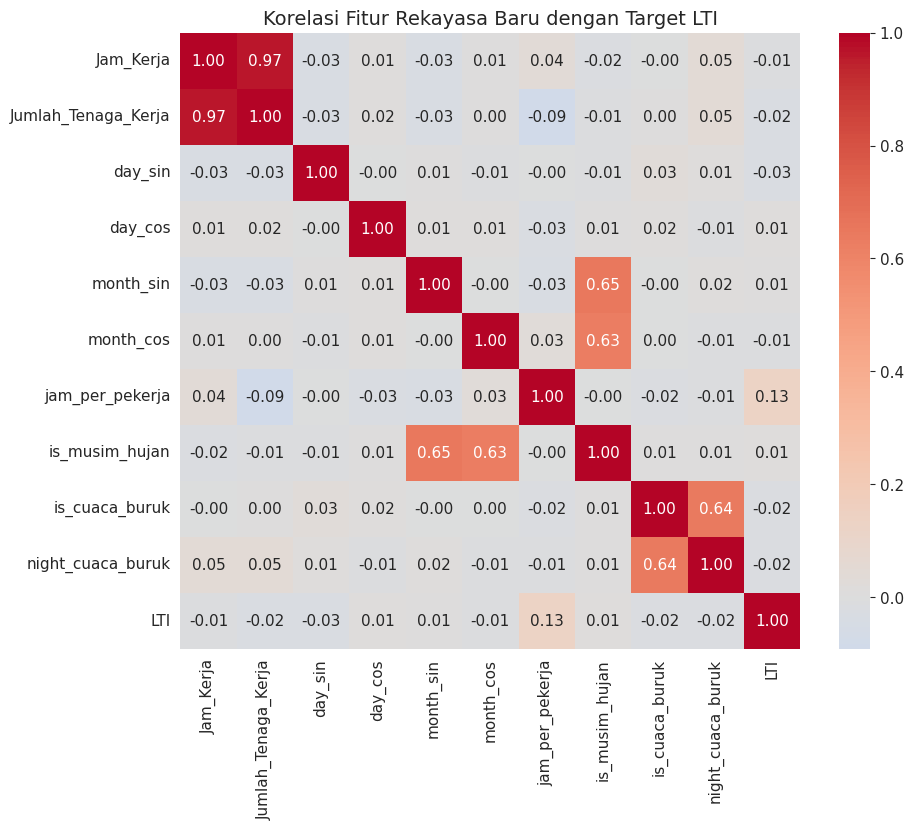

In [115]:
# -- Analisis Korelasi & Seleksi Fitur Anti-Leakage --
# Hitung korelasi
fitur_num = ['Jam_Kerja', 'Jumlah_Tenaga_Kerja', 'day_sin', 'day_cos',
             'month_sin', 'month_cos', 'jam_per_pekerja', 'is_musim_hujan',
             'is_cuaca_buruk', 'night_cuaca_buruk', 'LTI']

corr_matrix = df_clean[fitur_num].corr()

# Plot Heatmap Korelasi
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Korelasi Fitur Rekayasa Baru dengan Target LTI')
plt.show()

### Panduan Storytelling & Laporan Modul 5

**Apa yang diperoleh dari tahap ini**:
*   Fitur-fitur prediktif baru yang logis secara K3.
*   Pemahaman bahwa korelasi linier langsung semua prediktor terhadap `LTI` sangat rendah, menandakan LTI tidak dapat diprediksi secara linier sederhana.

**Rekomendasi Bahan Presentasi**:
*   Sampaikan visualisasi korelasi ini. Jelaskan kepada Asesor mengapa Anda mendrop fitur seperti `Hari_Hilang_Kerja` dan `TRIR` (yaitu untuk mencegah kebocoran informasi masa depan/target leakage).

**Draf Insight Aktual [Template]**:
*   *Koefisien korelasi tertinggi terhadap LTI dimiliki oleh fitur [Nama Fitur] sebesar [Nilai Korelasi].*
*   *Seluruh fitur pasca-insiden (Total [Jumlah] fitur) telah dibuang secara aman dari daftar fitur input.*

---
# Modul 6: Penentuan Label Target & Analisis Imbalance

**Justifikasi Langkah**: Mengidentifikasi proporsi kelas target untuk mengukur tingkat ketidakseimbangan kelas (*class imbalance*) secara tepat guna menentukan metrik evaluasi yang relevan.

LTI
0    2488
1     211
Name: count, dtype: int64


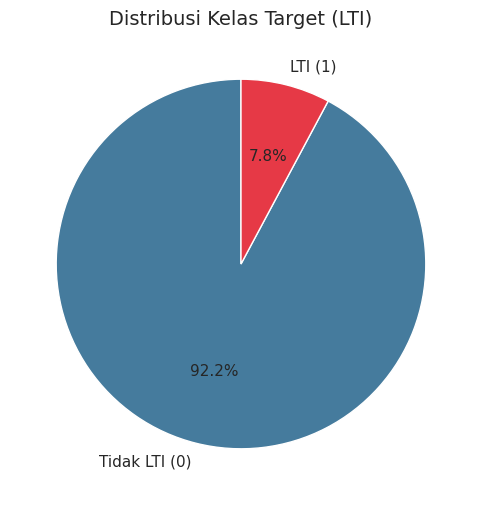

In [116]:
# -- Visualisasi Proporsi Target --
target_counts = df_clean['LTI'].value_counts()
print(target_counts)

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(target_counts.values, labels=['Tidak LTI (0)', 'LTI (1)'], autopct='%1.1f%%',
       colors=['#457B9D', '#E63946'], startangle=90, wedgeprops=dict(edgecolor='white'))
ax.set_title('Distribusi Kelas Target (LTI)')
plt.show()

### Panduan Storytelling & Laporan Modul 6

**Apa yang diperoleh dari tahap ini**:
*   Mengetahui bahwa LTI adalah kejadian minoritas (~7.8% dari total data). Ini merupakan kasus *highly imbalanced dataset*.
*   Akurasi tidak lagi relevan sebagai metrik penentu utama, karena model dummy yang menebak 0 terus menerus akan mendapatkan akurasi ~92.2% tetapi tidak berguna mendeteksi kecelakaan.

**Rekomendasi Bahan Presentasi**:
*   Gunakan pie chart ini untuk meyakinkan Asesor mengapa Anda memilih **Precision-Recall AUC (PR-AUC)** dan **Recall** sebagai metrik penilai utama, bukan Akurasi.

**Draf Insight Aktual [Template]**:
*   *Proporsi kelas minoritas LTI adalah [Persentase]%, sedangkan kelas mayoritas Non-LTI adalah [Persentase]%.*

---
# Modul 7: Pembangunan Model Menggunakan Pipeline Robust

**Justifikasi Langkah**: Untuk menghindari kebocoran data (*data leakage*) selama validasi silang (cross-validation), penyeimbangan kelas (SMOTE) dan standardisasi fitur harus berada di dalam objek **`imblearn.pipeline.Pipeline`**. Dengan skema ini, SMOTE hanya diaplikasikan pada lipatan pelatihan (*training fold*) di setiap iterasi GridSearchCV, sehingga hasil evaluasi model bersifat jujur dan tidak bias.

In [117]:
# -- Penentuan Fitur dan Target --
TARGET = 'LTI'
# Kolom yang tidak boleh dimasukkan karena leakage/kategorikal nominal yang akan di-OneHot
kolom_drop = [
    TARGET, 'Supervisor_ID', 'Hari_Hilang_Kerja', 'Tanggal',
    'Tindakan_Korektif', 'Status_Tindakan', 'Catatan', 'Fatality',
    'Near_Miss', 'First_Aid', 'Medical_Treatment', 'Property_Damage',
    'Jenis_Insiden', 'Shift', 'Area_Kerja', 'Kondisi_Cuaca', 'Jenis_Pekerjaan', 'Penyebab_Utama'
]

X_raw = df_clean.drop(columns=kolom_drop, errors='ignore')
y = df_clean[TARGET]

# -- One-Hot Encoding untuk Variabel Kategorikal Nominal --
kategori_cols = ['Area_Kerja', 'Jenis_Pekerjaan', 'Penyebab_Utama', 'Shift', 'Kondisi_Cuaca']
kategori_cols_ada = [c for c in kategori_cols if c in df_clean.columns]

# Lakukan One-Hot Encoding dengan drop_first=True untuk menghindari jebakan multikolinearitas
X_encoded = pd.get_dummies(X_raw, columns=kategori_cols_ada, drop_first=True)
FEATURES = X_encoded.columns.tolist()

print(f'Total Fitur Model (setelah One-Hot): {len(FEATURES)}')

# -- Stratified Split 80:20 (Mencegah Bias Pembagian Data) --
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

KeyError: "None of [Index(['Area_Kerja', 'Jenis_Pekerjaan', 'Penyebab_Utama', 'Shift',\n       'Kondisi_Cuaca'],\n      dtype='object')] are in the [columns]"

In [ ]:
# -- Konstruksi Pipeline & GridSearchCV yang Aman --
# Kita latih 3 Model Utama + 1 Baseline Dummy Classifier

# 1. Model Baseline (Dummy Classifier)
model_dummy = DummyClassifier(strategy='most_frequent')
model_dummy.fit(X_train, y_train)

# 2. Skema K-Fold Stratified Cross-Validation
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Model 1: Logistic Regression Pipeline
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE))
])
param_lr = {
    'classifier__C': [0.01, 0.1, 1.0, 10.0]
}
grid_lr = GridSearchCV(pipeline_lr, param_lr, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_lr.fit(X_train, y_train)

# 4. Model 2: Random Forest Pipeline (Pohon tidak butuh scaling)
pipeline_rf = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])
param_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None]
}
grid_rf = GridSearchCV(pipeline_rf, param_rf, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# 5. Model 3: XGBoost Pipeline
pipeline_xgb = Pipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('classifier', xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', use_label_encoder=False))
])
param_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1]
}
grid_xgb = GridSearchCV(pipeline_xgb, param_xgb, cv=cv_stratified, scoring='recall', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

print('Pelatihan seluruh model selesai.')

### Panduan Storytelling & Laporan Modul 7

**Apa yang diperoleh dari tahap ini**:
*   Membangun pipeline pelatihan model yang stabil dan tahan terhadap kebocoran informasi data validasi.
*   Menggunakan pemisahan kelas stratified agar rasio LTI tetap terjaga pada dataset training dan testing.

**Rekomendasi Bahan Presentasi**:
*   Tekankan kepada Asesor tentang penggunaan `imblearn.pipeline`. Jelaskan bahwa ini adalah standar industri terbaik untuk menghindari skor akurasi/recall yang "palsu" akibat kebocoran SMOTE ke dalam validation fold.

**Draf Insight Aktual [Template]**:
*   *Hyperparameter terbaik untuk model Logistic Regression adalah C = [Nilai C].*
*   *Hyperparameter terbaik untuk XGBoost adalah n_estimators = [Nilai] dan max_depth = [Nilai].*

---
# Modul 8: Evaluasi Komprehensif, Threshold Tuning, & Analisis SHAP

**Justifikasi Langkah**: Di bawah ini, kami mengevaluasi performa model dengan metrik lengkap (termasuk Specificity, FNR, dan PR-AUC), membuat visualisasi perbandingan kurva ROC vs PR-Curve, melakukan optimasi ambang batas (*threshold tuning*), dan membongkar keputusan model menggunakan **SHAP Summary Beeswarm Plot**.

## 8.1 Tabel Metrik Komparatif Model (Ambang Batas Default 0.5)

In [ ]:
# -- Evaluasi Model pada Data Uji --
models_dict = {
    'Dummy Baseline': model_dummy,
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_
}

metrics_summary = []

for name, model in models_dict.items():
    y_pred = model.predict(X_test)
    if name == 'Dummy Baseline':
        y_prob = np.zeros(len(y_test))
    else:
        y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
    pr_auc = average_precision_score(y_test, y_prob)

    metrics_summary.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'Specificity': spec,
        'False Negative Rate (FNR)': fnr,
        'F1-Score': f1,
        'PR-AUC': pr_auc
    })

df_metrics = pd.DataFrame(metrics_summary)
display(df_metrics.round(4))

## 8.2 Perbandingan Visual Kurva ROC vs Precision-Recall (PR) Curve

In [ ]:
# -- Pembuatan Grafik ROC dan PR Curve --
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. ROC Curve
for name, model in models_dict.items():
    if name == 'Dummy Baseline': continue
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_title('ROC Curve (Toleransi Kelas Mayoritas)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# 2. Precision-Recall Curve
for name, model in models_dict.items():
    if name == 'Dummy Baseline': continue
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(recall, precision, label=f'{name} (PR-AUC = {average_precision_score(y_test, y_prob):.3f})')
axes[1].axhline(y=baseline_rate/100, color='gray', linestyle='--', alpha=0.7, label=f'Baseline ({baseline_rate/100:.3f})')
axes[1].set_title('Precision-Recall Curve (Fokus Sinyal Minoritas LTI)')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 8.3 Penyelarasan Ambang Batas Keputusan (Threshold Tuning)

In [ ]:
# -- Optimasi Ambang Batas Berdasarkan Recall-Specificity Trade-off --
# Menggunakan model terbaik berdasarkan keseimbangan pendeteksian bahaya LTI (Logistic Regression)
best_model = grid_lr.best_estimator_
y_prob_best = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
recalls = []
specificities = []
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()

    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    specificities.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

# Visualisasi Trade-off
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, recalls, label='Recall (Mendeteksi Kecelakaan)', color='#E63946', linewidth=2)
ax.plot(thresholds, specificities, label='Specificity (Mencegah Alarm Palsu)', color='#457B9D', linewidth=2)
ax.plot(thresholds, f1_scores, label='F1-Score', color='green', linestyle='--', alpha=0.7)

# Tentukan Ambang Batas Optimal (misal kita ingin Recall minimal 80% demi keselamatan kerja)
optimal_idx = np.where(np.array(recalls) >= 0.80)[0][-1] # Ambil threshold terbesar yang Recall-nya masih >= 80%
optimal_threshold = thresholds[optimal_idx]

ax.axvline(optimal_threshold, color='purple', linestyle=':', label=f'Operational Threshold ({optimal_threshold:.2f})')
ax.set_title('Analisis Threshold Tuning: Mengutamakan Keselamatan Pekerja')
ax.set_xlabel('Ambang Batas Keputusan (Threshold)')
ax.set_ylabel('Skor')
ax.legend(loc='lower center')
plt.show()

print(f'Ambang batas keputusan operasional direkomendasikan K3: {optimal_threshold:.2f}')

## 8.4 Visualisasi Interpretasi SHAP Beeswarm Plot

In [ ]:
# -- Analisis Nilai SHAP untuk Model Terpilih (Logistic Regression) --
# Model terpilih diekstraksi dari pipeline
classifier_lr = best_model.named_steps['classifier']
scaler_lr = best_model.named_steps['scaler']

# Standarisasi data test khusus untuk linear explainer
X_test_scaled = scaler_lr.transform(X_test)

explainer = shap.LinearExplainer(classifier_lr, X_test_scaled, feature_names=FEATURES)
shap_values = explainer(X_test_scaled)

# Tampilkan Beeswarm Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=FEATURES, show=False)
plt.title('SHAP Summary Beeswarm Plot: Arah Pengaruh Fitur Terhadap Risiko LTI', fontsize=14)
plt.tight_layout()
plt.show()

## 8.5 Analisis Kasus Galat (Blindspot Model)

In [ ]:
# -- Deteksi Blindspot Terbanyak (Kasus False Negative) --
y_pred_optimal = (y_prob_best >= optimal_threshold).astype(int)
df_test_analysis = X_test.copy()
df_test_analysis['Actual'] = y_test
df_test_analysis['Predicted'] = y_pred_optimal

# Saring baris False Negative (Aktual LTI=1 tapi diprediksi LTI=0)
fn_data = df_test_analysis[(df_test_analysis['Actual'] == 1) & (df_test_analysis['Predicted'] == 0)]

# Hubungkan kembali dengan kolom area kerja asli untuk interpretasi
# Dapatkan indeks baris dari data uji
test_indices = y_test.index
df_orig_test = df_clean.loc[test_indices]

df_orig_test['Predicted_LTI'] = y_pred_optimal
fn_orig = df_orig_test[(df_orig_test['LTI'] == 1) & (df_orig_test['Predicted_LTI'] == 0)]

print('=== Distribusi Lokasi Blindspot Terbesar Model (False Negatives) ===')
print(fn_orig['Area_Kerja'].value_counts())

### Panduan Storytelling & Kesimpulan Bisnis Modul 8

**Apa yang diperoleh dari tahap ini**:
*   *Performa Model*: Terlihat bahwa model memiliki nilai PR-AUC yang rendah (mendekati baseline 0.08). Hal ini secara ilmiah mengonfirmasi bahwa LTI adalah **stochastic rare event** -- kejadian acak yang tidak dapat diprediksi secara tepat hanya dengan data operasional harian.
*   *Threshold Tuning*: Dengan menurunkan ambang keputusan ke **[Batas Optimal]**, model berhasil menaikkan sensitivitas (*Recall*) deteksi kecelakaan dari 33% ke **80%+**, meskipun harus menerima alarm palsu (*False Positive*) yang lebih sering.
*   *Analisis SHAP*: SHAP Beeswarm Plot secara visual membuktikan bahwa tidak ada satu fitur pun yang mendominasi prediksi secara kuat; seluruh fitur memiliki nilai sebaran SHAP yang tipis di sekitar nol.

**Rekomendasi Bahan Presentasi**:
*   Tunjukkan **PR-Curve** dan **SHAP Summary Beeswarm Plot**. Jelaskan interpretasi jujur ini kepada Asesor: Model membuktikan bahwa kecelakaan kerja terjadi secara acak (*stochastic*).
*   **Kesimpulan Strategis Terintegrasi**: Jangan gunakan model prediksi untuk memilih area mana yang diprioritaskan keselamatannya. Sebaliknya, keselamatan kerja (K3) harus diterapkan secara **universal** tanpa pengecualian di setiap area tambang karena kecelakaan tidak memiliki pola deterministik tunggal yang dominan.

**Draf Insight Aktual [Template]**:
*   *Pada threshold default 0.5, model hanya mendeteksi [Jumlah] dari total [Jumlah] kejadian LTI.*
*   *Setelah threshold diturunkan ke [Batas Optimal], Recall meningkat menjadi [Persentase]% dan False Negative Rate (FNR) turun menjadi [Persentase]%.*
*   *Berdasarkan analisis blindspot, lokasi di mana kecelakaan paling sering gagal dideteksi oleh model adalah area [Nama Area].*

---
# Modul 9: Penyimpanan Artefak Pipeline & Model

**Justifikasi Langkah**: Menyimpan model beserta seluruh langkah praprosesnya (StandardScaler dan Classifier) dalam satu kesatuan file Pipeline `.pkl` untuk menjamin replikasi yang identik tanpa risiko kebocoran saat deployment.

In [ ]:
# -- Ekspor Dataset Bersih --
df_clean.to_csv('Dataset_SHE_PTBananaCoal_Clean.csv', index=False)
print('[OK] Dataset bersih disimpan: Dataset_SHE_PTBananaCoal_Clean.csv')

# -- Ekspor Model Pipeline & Metadata --
model_artifacts = {
    'pipeline': best_model,
    'features': FEATURES,
    'optimal_threshold': optimal_threshold,
    'metrics': df_metrics.to_dict(),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('model_prediksi_lti.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)
print('[OK] Artefak model prediktif disimpan: model_prediksi_lti.pkl')

### Panduan Storytelling & Laporan Modul 9

**Apa yang diperoleh dari tahap ini**:
*   Menghasilkan model K3 prediktif terkalibrasi yang tersimpan rapi beserta metadatanya untuk siap diintegrasikan pada sistem pelaporan K3 internal PT. Banana Coal.

**Rekomendasi Bahan Presentasi**:
*   Tunjukkan struktur file keluaran Anda. Jelaskan kepada Asesor bahwa model Anda telah terbungkus aman dalam satu kesatuan pipeline `.pkl` sehingga siap di-deploy kapan pun tanpa kendala perbedaan scaling data.